# Перцептрон

In [466]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

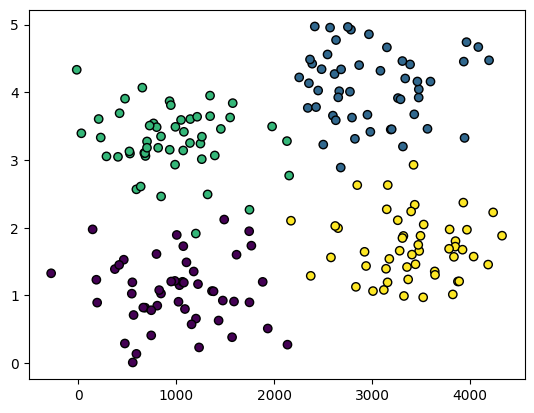

In [467]:
blob_centers = ([1, 1], [3, 4], [1, 3.3], [3.5, 1.8])
X, y = make_blobs(n_samples=200, 
                          centers=blob_centers, 
                          cluster_std=0.5,
                          random_state=0)

X[:, 0] *= 1000

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

In [468]:
from sklearn.neural_network import MLPClassifier
clf = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1).fit(X, y)
print("Веса между входным и скрытым слоем:")
print(clf.coefs_[0])
print("\nВеса между скрытым и выходным слоем:")
print(clf.coefs_[1])

Веса между входным и скрытым слоем:
[[-0.09809877  0.33667051 -0.82024119 -0.29720839 -0.56852789 -0.66056109]
 [-0.58903611 -0.31219238 -0.22424296  0.11423652 -0.18324369  0.37321781]]

Веса между скрытым и выходным слоем:
[[-0.51316658 -0.43365467  0.43189995  0.68148414]
 [-0.24370005  0.34328608  0.57835494  0.57889271]
 [-0.59713359 -0.67678056 -0.46609801  0.54011704]
 [-0.5769702  -0.10221922  0.75476969  0.00610289]
 [ 0.34285864 -0.25645017  0.33417991  0.47281254]
 [-0.7006119   0.35515533  0.80295119  0.33880635]]


In [469]:
for i in range(len(clf.coefs_)):
    number_neurons_in_layer = clf.coefs_[i].shape[1]
    for j in range(number_neurons_in_layer):
        weights = clf.coefs_[i][:,j]
        print(i, j, weights, end=", ")
        print()
    print()

0 0 [-0.09809877 -0.58903611], 
0 1 [ 0.33667051 -0.31219238], 
0 2 [-0.82024119 -0.22424296], 
0 3 [-0.29720839  0.11423652], 
0 4 [-0.56852789 -0.18324369], 
0 5 [-0.66056109  0.37321781], 

1 0 [-0.51316658 -0.24370005 -0.59713359 -0.5769702   0.34285864 -0.7006119 ], 
1 1 [-0.43365467  0.34328608 -0.67678056 -0.10221922 -0.25645017  0.35515533], 
1 2 [ 0.43189995  0.57835494 -0.46609801  0.75476969  0.33417991  0.80295119], 
1 3 [0.68148414 0.57889271 0.54011704 0.00610289 0.47281254 0.33880635], 



In [470]:
print("Веса смещения для скрытого слоя:")
print(clf.intercepts_[0])
print("\nВеса смещения для выходного слоя:")
print(clf.intercepts_[1])

Веса смещения для скрытого слоя:
[-0.55752645  0.60978582 -0.8640854   0.33258994 -0.18652436  0.05696655]

Веса смещения для выходного слоя:
[-0.29413473  0.49414359 -0.60792984 -0.11888525]


In [471]:
from sklearn.metrics import accuracy_score, confusion_matrix
confusion_matrix(y, clf.predict(X))

array([[ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50],
       [ 0,  0,  0, 50]])

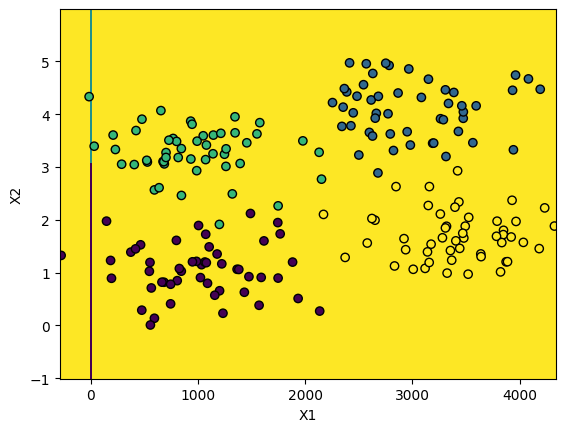

In [472]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [473]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

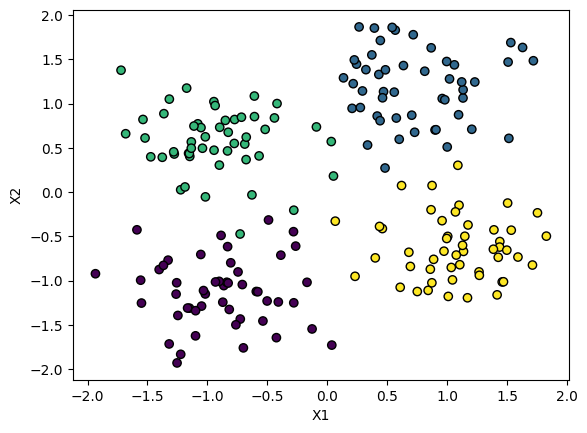

In [474]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

In [475]:
clf_scaled = MLPClassifier(hidden_layer_sizes=(6,), 
                    random_state=1, max_iter=10000).fit(X, y)

from sklearn.metrics import confusion_matrix
confusion_matrix(y, clf_scaled.predict(X))

array([[50,  0,  0,  0],
       [ 0, 49,  0,  1],
       [ 2,  3, 45,  0],
       [ 0,  1,  0, 49]])

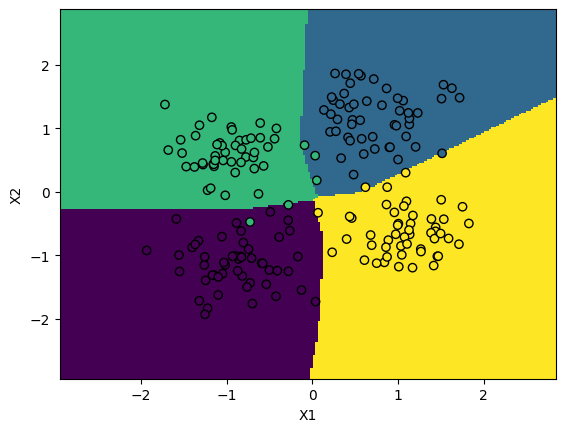

In [476]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_scaled.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

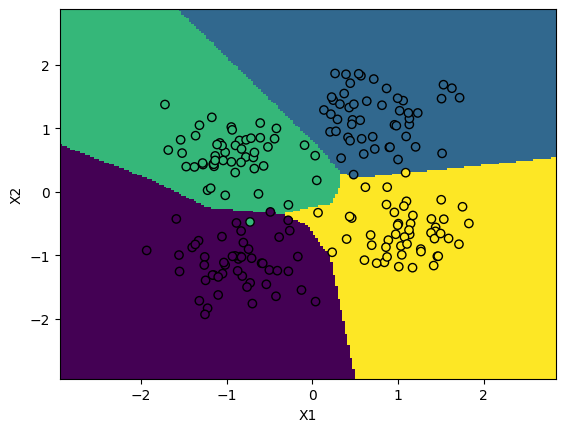

In [477]:
clf = MLPClassifier(hidden_layer_sizes=(6, 6, 6), max_iter=10_000).fit(X, y)
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

## Задания для самостоятельного выполнения

In [478]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 1. Создайте однослойный перцептрон с 1, 2, 10 и 100 нейронами. Сравние их точность и сделайте вывод о достаточном количестве нейронов.

In [ ]:
from sklearn.metrics import accuracy_score

neurons = [1, 2, 10, 100]

for n in neurons:
    clf = MLPClassifier(hidden_layer_sizes=(n,), max_iter=10000, random_state=1)
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    print("Neurons:", n, "Accuracy:", acc)

Neurons: 1 Accuracy: 0.25
Neurons: 2 Accuracy: 0.98
Neurons: 10 Accuracy: 0.98
Neurons: 100 Accuracy: 0.995


#### 2. Создайте и оцените модель с двумя, тремя и десятью скрытыми слоями с одинаковым количеством нейронов. Сравните их точность и сделайте вывод о достаточном количестве слоев.

In [ ]:
layers = [
    (6,6),
    (6,6,6),
    (6,6,6,6,6,6,6,6,6,6)
]

for l in layers:
    clf = MLPClassifier(hidden_layer_sizes=l, max_iter=10000, random_state=1)
    clf.fit(X_scaled, y)
    y_pred = clf.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    print("Layers:", l, "Accuracy:", acc)

Layers: (6, 6) Accuracy: 0.99
Layers: (6, 6, 6) Accuracy: 0.985
Layers: (6, 6, 6, 6, 6, 6, 6, 6, 6, 6) Accuracy: 0.75


#### 3. Для глубокой модели выведите веса всех нейронов на всех слоях. Выведите значения векторов весов смещения.

In [481]:
clf = MLPClassifier(hidden_layer_sizes=(6,6,6), max_iter=10000, random_state=1)
clf.fit(X_scaled, y)

for i in range(len(clf.coefs_)):
    print(f"layer {i} weights (shape {clf.coefs_[i].shape}):")
    print(clf.coefs_[i])
    print(f"layer {i} biases (shape {clf.intercepts_[i].shape}):")
    print(clf.intercepts_[i])

layer 0 weights (shape (2, 6)):
[[-0.56393297  0.60822648 -1.17549316 -0.47484355 -0.97469482 -0.89551464]
 [-1.04377617 -0.9716159  -0.84115601  0.05446173 -0.15414077 -0.09682711]]
layer 0 biases (shape (6,)):
[-0.07901987  0.38648129 -0.21165523  0.42243687  0.44862795  0.41934324]
layer 1 weights (shape (6, 6)):
[[-0.39003205  0.72891622  0.79693306  1.06431415 -0.59980821  0.15577028]
 [ 1.19238708  1.39482637 -0.87802197  0.02069315 -0.64131048  1.05559926]
 [-1.26564349 -0.80052824  1.14948887  0.51607981  0.12659614 -0.31751319]
 [ 0.45486147  0.00841445 -0.27863804  0.95659735  0.86502853  0.18754973]
 [-1.27185357  0.4903548  -0.56744811  0.59958166  0.73322238 -0.51040571]
 [-1.22170932 -0.61436213 -0.64817297  0.86782495 -0.17277008 -0.55444431]]
layer 1 biases (shape (6,)):
[ 0.98376742 -0.25620136  0.9882414   0.0454231   0.22069224  0.34152229]
layer 2 weights (shape (6, 6)):
[[-7.54599625e-01  5.67430889e-01  3.92887331e-05  4.22893707e-01
  -1.45037204e+00  8.72013529e

#### 4. Постройте и оцените модель с большим количеством нейронов и слоев. Замерьте время выполнения обучения, сравните со временем обучения более простых моделей.

In [ ]:
import time

start = time.time()
clf_simple = MLPClassifier(hidden_layer_sizes=(6,), max_iter=5000, random_state=1)
clf_simple.fit(X_scaled, y)
end = time.time()
simple_time = end - start
simple_acc = accuracy_score(y, clf_simple.predict(X_scaled))
print(f"simple model training time: {simple_time:.4f}s")
print(f"simple model accuracy: {simple_acc:.4f}")

simple model training time: 0.4311s
simple model accuracy: 0.9650


In [ ]:
start = time.time()
clf_big = MLPClassifier(hidden_layer_sizes=(100,100,100), max_iter=10000, random_state=1)
clf_big.fit(X_scaled, y)
end = time.time()
big_time = end - start
big_acc = accuracy_score(y, clf_big.predict(X_scaled))
print(f"large model training time: {big_time:.4f}s")
print(f"large model accuracy: {big_acc:.4f}")
print(f"comparison: large model is {big_time/simple_time:.2f}x slower")

large model training time: 0.3052s
large model accuracy: 0.9900
comparison: large model is 0.71x slower


#### 5. Постройте и оцените модель классификации с помощью перцептрона на датасете, который вы использовали на контрольной по классификиации (если вы ее не выполняли, возьмите любой датасет из раздела "real world datasets" в библиотеке sklearn).

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

data = load_breast_cancer()

print("features:", data.feature_names)
print("classes :", data.target_names)

X = data.data
y = data.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
clf = MLPClassifier(hidden_layer_sizes=(10,10), max_iter=10000, random_state=1)
clf.fit(X_scaled, y)
y_pred = clf.predict(X_scaled)
print(f"accuracy: {accuracy_score(y, y_pred)}")
print("confusion matrix:")
print(confusion_matrix(y, y_pred))

features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
classes : ['malignant' 'benign']
accuracy: 0.9947275922671354
confusion matrix:
[[209   3]
 [  0 357]]


#### 6. Постройте и оцените модель регрессии с помощью перцептрона на датасете, который вы использовали на контрольной по регрессии.

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = MLPRegressor(hidden_layer_sizes=(20,20), max_iter=10000, random_state=1)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print("R^2 score:", r2_score(y_test, y_pred))

R^2 score: -0.3472893876113192
